In [1]:
import os
# cwd =  os.getcwd().replace("small-benchmarks","")
cwd =  os.getcwd()
os.chdir(cwd)
os.getcwd()

'/Users/ian_moore/repos/ngf-alpha/small-benchmarks'

In [ ]:
# print("H_raw shape:", tuple(H_raw.shape))
# print("tokenwise std raw:", H_raw.std(dim=0).mean().item())
# print("tokenwise std warp:", H_warp.std(dim=0).mean().item())
# print("alpha,beta:", torch.nn.functional.softplus(wm.alpha).item(),
#                     torch.nn.functional.softplus(wm.beta).item())
# print("||center||:", wm.center.norm().item())


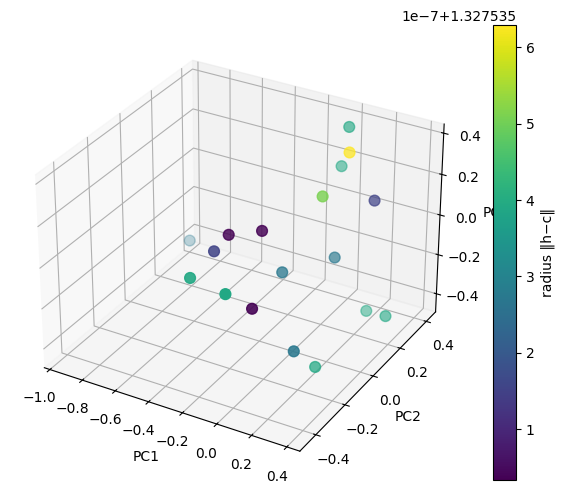

In [2]:
# 01_load_and_probe.py
import torch, matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from wellmetric_ft import attach_wellmetric
import torch, matplotlib.pyplot as plt


ckpt = torch.load("wellmetric_gpt2_layer9.pt", map_location="cpu")
model = AutoModelForCausalLM.from_pretrained(ckpt["model_name"])
wm, cache, handle = attach_wellmetric(model, layer_idx=ckpt["layer_idx"])
wm.load_state_dict(ckpt["state_dict"])
model.eval()

tok = AutoTokenizer.from_pretrained(ckpt["model_name"])
text = "In a quiet village, a curious child asked a difficult question about the nature of truth."
inputs = tok(text, return_tensors="pt")

with torch.no_grad():
    _ = model(**inputs)                # fills cache["pre"] with pre-warp h
import torch, matplotlib.pyplot as plt

import torch, numpy as np, matplotlib.pyplot as plt

# Ensure [T,D]
H_raw = cache["pre"]
if H_raw.dim() == 3: H_raw = H_raw[0]
H_warp = wm(H_raw).detach().cpu().to(torch.float32)    # [T,D]

# Mean-center
X = H_warp - H_warp.mean(0, keepdim=True)              # [T,D]

# If X is near-zero, bail early with a message
if X.abs().max().item() < 1e-8:
    print("X is (near) zero; feed more/longer text or stack multiple samples.")
else:
    # SVD-based PCA
    U, S, Vh = torch.linalg.svd(X, full_matrices=False)
    k = min(3, S.numel())
    Z = (U[:, :k] * S[:k])                             # [T,k]
    Z3 = Z.detach().cpu().numpy()

    # Radius per token
    center = wm.center.detach().cpu().view(-1)         # [D]
    r = torch.norm(H_warp - center.unsqueeze(0), dim=-1).cpu().numpy()  # [T]

    # Plot
    import matplotlib.pyplot as plt
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    if Z3.shape[1] == 3:
        sc = ax.scatter(Z3[:,0], Z3[:,1], Z3[:,2], c=r, cmap='viridis', s=60)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
    elif Z3.shape[1] == 2:
        sc = ax.scatter(Z3[:,0], Z3[:,1], c=r, cmap='viridis', s=60)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    else:
        sc = ax.scatter(np.arange(Z3.shape[0]), Z3[:,0], c=r, cmap='viridis', s=60)
        ax.set_xlabel('token'); ax.set_ylabel('PC1')
    plt.colorbar(sc, label='radius ‖h−c‖')
    plt.tight_layout(); plt.show()

/var/folders/97/wcmz4r710pj20v_3cnvl09cm0000gn/T/ipykernel_23245/1317741225.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


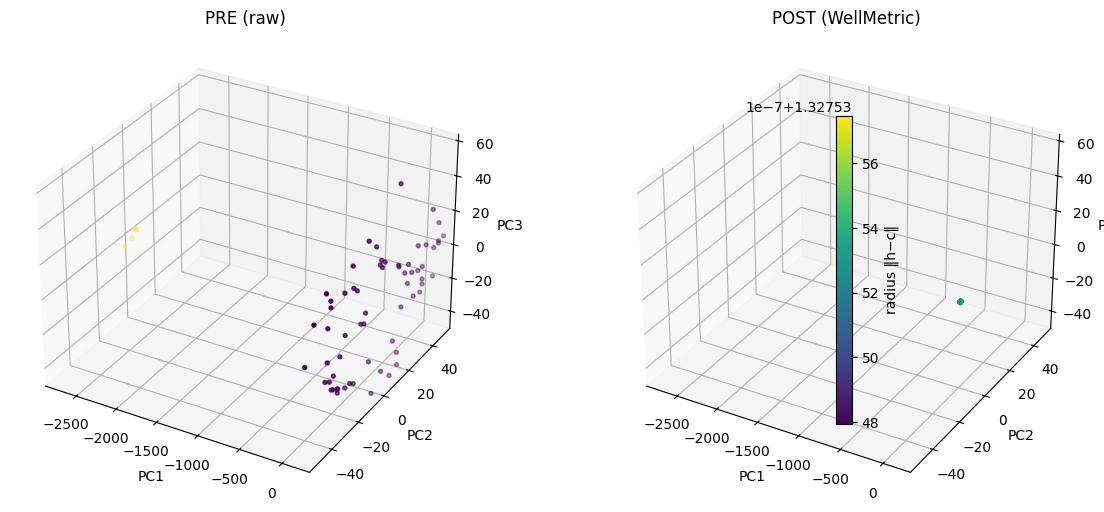

mean radius  pre→post: 376.1148 → 1.3275354
std  radius  pre→post: 766.10095 → 1.9662626e-07


In [5]:
# 1) Tokenize a small batch
tok.pad_token = tok.eos_token
tok.padding_side = "right"

texts = [
  "In a quiet village, a curious child asked a question about truth.",
  "The elder replied with a parable about mirrors and light and angles.",
  "Years later, the student revisited the riddle with first principles.",
  "Mathematics reveals symmetry: structures invariant under transformation.",
  "Cooking pasta requires boiling water; salting early changes starch release."
]
batch = tok(texts, return_tensors="pt", padding=True, truncation=True, max_length=160)

# 2) Forward → collect pre-warp activations
with torch.no_grad():
    _ = model(**batch)
H_pre = cache["pre"]                      # [B,T,D]
mask  = batch["attention_mask"].bool()
rows = [H_pre[b][mask[b]] for b in range(H_pre.size(0))]
H_raw  = torch.cat(rows, dim=0)          # [N,D]
H_post = wm(H_raw).detach()              # [N,D]

# 3) Shared PCA basis (SVD, robust)
def center(M): return M - M.mean(0, keepdim=True)
X_raw  = center(H_raw).to(torch.float32)
X_post = center(H_post).to(torch.float32)
X_cat  = torch.cat([X_raw, X_post], dim=0)

U,S,Vh = torch.linalg.svd(X_cat, full_matrices=False)
V = Vh.T[:, :3]                           # [D,3] shared basis
Z_raw  = (X_raw  @ V).cpu().numpy()
Z_post = (X_post @ V).cpu().numpy()

# 4) Colors = per-token radius after warp
c = wm.center.detach().view(1, -1)
r_raw  = torch.norm(H_raw  - c, dim=1).cpu().numpy()
r_post = torch.norm(H_post - c, dim=1).cpu().numpy()

# 5) Side-by-side plots with identical limits
import numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

lims = np.array([
    [Z_raw[:,0].min(),  Z_raw[:,0].max(),  Z_post[:,0].min(), Z_post[:,0].max()],
    [Z_raw[:,1].min(),  Z_raw[:,1].max(),  Z_post[:,1].min(), Z_post[:,1].max()],
    [Z_raw[:,2].min(),  Z_raw[:,2].max(),  Z_post[:,2].min(), Z_post[:,2].max()],
])
xmin,xmax = lims[0].min(), lims[0].max()
ymin,ymax = lims[1].min(), lims[1].max()
zmin,zmax = lims[2].min(), lims[2].max()

fig = plt.figure(figsize=(12,5))
ax1 = fig.add_subplot(1,2,1, projection='3d')
sc1 = ax1.scatter(Z_raw[:,0], Z_raw[:,1], Z_raw[:,2], c=r_raw, cmap='viridis', s=8)
ax1.set_title("PRE (raw)");  ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.set_zlabel('PC3')
ax1.set_xlim(xmin,xmax); ax1.set_ylim(ymin,ymax); ax1.set_zlim(zmin,zmax)

ax2 = fig.add_subplot(1,2,2, projection='3d')
sc2 = ax2.scatter(Z_post[:,0], Z_post[:,1], Z_post[:,2], c=r_post, cmap='viridis', s=8)
ax2.set_title("POST (WellMetric)"); ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.set_zlabel('PC3')
ax2.set_xlim(xmin,xmax); ax2.set_ylim(ymin,ymax); ax2.set_zlim(zmin,zmax)

cbar = fig.colorbar(sc2, ax=[ax1, ax2], shrink=0.8, pad=0.05)
cbar.set_label('radius ‖h−c‖')
plt.tight_layout(); plt.show()

print("mean radius  pre→post:", r_raw.mean(), "→", r_post.mean())
print("std  radius  pre→post:", r_raw.std(),  "→", r_post.std())


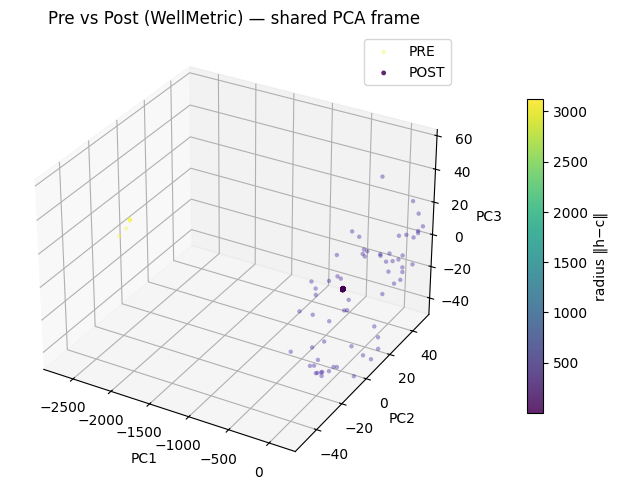

mean radius  pre→post: 376.1148 → 1.3275354
std  radius  pre→post: 766.10095 → 1.9662626e-07


In [6]:
# 04_overlay_3d.py
import torch, numpy as np, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa

tok.pad_token = tok.eos_token
tok.padding_side = "right"

texts = [
  "In a quiet village, a curious child asked a question about truth.",
  "The elder replied with a parable about mirrors and light and angles.",
  "Years later, the student revisited the riddle with first principles.",
  "Mathematics reveals symmetry: structures invariant under transformation.",
  "Cooking pasta requires boiling water; salting early changes starch release."
]
batch = tok(texts, return_tensors="pt", padding=True, truncation=True, max_length=160)
with torch.no_grad():
    _ = model(**batch)

H_pre = cache["pre"]                      # [B,T,D]
mask  = batch["attention_mask"].bool()
rows = [H_pre[b][mask[b]] for b in range(H_pre.size(0))]
H_raw  = torch.cat(rows, dim=0)          # [N,D]
H_post = wm(H_raw).detach()              # [N,D]

def center(M): return M - M.mean(0, keepdim=True)
X_raw  = center(H_raw).to(torch.float32)
X_post = center(H_post).to(torch.float32)
X_cat  = torch.cat([X_raw, X_post], dim=0)

# SVD PCA on concatenated data → shared basis
U,S,Vh = torch.linalg.svd(X_cat, full_matrices=False)
V = Vh.T[:, :3]                                 # [D,3]
Z_raw  = (X_raw  @ V).cpu().numpy()             # [N,3]
Z_post = (X_post @ V).cpu().numpy()             # [N,3]

# Colors = per-token radius; share same min/max
cvec   = wm.center.detach().view(1, -1)
r_raw  = torch.norm(H_raw  - cvec, dim=1).cpu().numpy()
r_post = torch.norm(H_post - cvec, dim=1).cpu().numpy()
vmin, vmax = min(r_raw.min(), r_post.min()), max(r_raw.max(), r_post.max())

fig = plt.figure(figsize=(9,5))
ax = fig.add_subplot(111, projection='3d')

# PRE (purple-ish) and POST (green-ish), semi-transparent, same limits
sc1 = ax.scatter(Z_raw[:,0], Z_raw[:,1], Z_raw[:,2],
                 c=r_raw, cmap='plasma', vmin=vmin, vmax=vmax,
                 s=10, alpha=0.35, edgecolors='none', label='PRE')
sc2 = ax.scatter(Z_post[:,0], Z_post[:,1], Z_post[:,2],
                 c=r_post, cmap='viridis', vmin=vmin, vmax=vmax,
                 s=12, alpha=0.85, edgecolors='none', label='POST')

# Fit identical axis limits to both clouds
allX = np.concatenate([Z_raw[:,0], Z_post[:,0]])
allY = np.concatenate([Z_raw[:,1], Z_post[:,1]])
allZ = np.concatenate([Z_raw[:,2], Z_post[:,2]])
ax.set_xlim(allX.min(), allX.max()); ax.set_ylim(allY.min(), allY.max()); ax.set_zlim(allZ.min(), allZ.max())
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3')
ax.set_title('Pre vs Post (WellMetric) — shared PCA frame')
cb = fig.colorbar(sc2, pad=0.08, shrink=0.7); cb.set_label('radius ‖h−c‖')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("pca3_overlay_pre_post.png", dpi=220)
plt.show()

print("mean radius  pre→post:", r_raw.mean(), "→", r_post.mean())
print("std  radius  pre→post:",  r_raw.std(),  "→",  r_post.std())
